<a href="https://colab.research.google.com/github/ehiabh1/turbofan.rul/blob/main/01_data_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [37]:
import os
if not os.path.exists("/content/turbofan.rul"):
    !git clone https://github.com/ehiabh1/turbofan.rul.git
%cd /content/turbofan.rul
!git pull

/content/turbofan.rul
Already up to date.


In [38]:
!wget -q https://data.nasa.gov/docs/legacy/CMAPSSData.zip
!unzip -o -q CMAPSSData.zip -d cmapss_raw
!ls cmapss_raw
!find cmapss_raw -name "*_FD001.txt" -exec cp {} data/ \;
!ls data

'Damage Propagation Modeling.pdf'   RUL_FD004.txt    train_FD001.txt
 readme.txt			    test_FD001.txt   train_FD002.txt
 RUL_FD001.txt			    test_FD002.txt   train_FD003.txt
 RUL_FD002.txt			    test_FD003.txt   train_FD004.txt
 RUL_FD003.txt			    test_FD004.txt
README.md  RUL_FD001.txt  test_FD001.txt  train_FD001.txt


# **Data integrity**
FD001: 100 training engines run to failure, 100 test engines cut off early. All checks pass: no missing values, no duplicates, continuous cycle counts, and no rows shared between train and test (no leakage)

In [39]:
from src.load_data import load_fd
train, test, rul = load_fd("FD001")
feat = [c for c in train.columns if c not in ("unit", "cycle", "RUL")]

def cycles_ok(df):
    return df.groupby("unit")["cycle"].apply(
        lambda c: c.tolist() == list(range(1, len(c) + 1))).all()

checks = {
    "train: 20631 rows, 100 engines": len(train) == 20631 and train["unit"].nunique() == 100,
    "test: 13096 rows, 100 engines": len(test) == 13096 and test["unit"].nunique() == 100,
    "one RUL value per test engine": len(rul) == test["unit"].nunique(),
    "no missing values": not train.isna().any().any() and not test.isna().any().any(),
    "no duplicate rows within train/test": not train.duplicated().any() and not test.duplicated().any(),
    "cycles go 1,2,3... with no gaps": cycles_ok(train) and cycles_ok(test),
    "single operating condition (op3 constant)": train["op3"].nunique() == 1,
    "no identical rows shared by train and test": len(train[feat].merge(test[feat])) == 0,
}
for name, ok in checks.items():
    print("PASS" if ok else "FAIL", "-", name)

PASS - train: 20631 rows, 100 engines
PASS - test: 13096 rows, 100 engines
PASS - one RUL value per test engine
PASS - no missing values
PASS - no duplicate rows within train/test
PASS - cycles go 1,2,3... with no gaps
PASS - single operating condition (op3 constant)
PASS - no identical rows shared by train and test


In [40]:
last = test.groupby("unit").tail(1)
print((last["RUL"].values == rul["RUL"].values).all())
print(test["RUL"].isna().sum())

True
0


In [41]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
unit,20631.0,51.506568,2.922763e+01,1.0000,26.0000,52.0000,77.0000,100.0000
cycle,20631.0,108.807862,6.888099e+01,1.0000,52.0000,104.0000,156.0000,362.0000
op1,20631.0,-0.000009,2.187313e-03,-0.0087,-0.0015,0.0000,0.0015,0.0087
op2,20631.0,0.000002,2.930621e-04,-0.0006,-0.0002,0.0000,0.0003,0.0006
op3,20631.0,100.000000,0.000000e+00,100.0000,100.0000,100.0000,100.0000,100.0000
s1,20631.0,518.670000,6.537152e-11,518.6700,518.6700,518.6700,518.6700,518.6700
s2,20631.0,642.680934,5.000533e-01,641.2100,642.3250,642.6400,643.0000,644.5300
s3,20631.0,1590.523119,6.131150e+00,1571.0400,1586.2600,1590.1000,1594.3800,1616.9100
s4,20631.0,1408.933782,9.000605e+00,1382.2500,1402.3600,1408.0400,1414.5550,1441.4900
s5,20631.0,14.620000,3.394700e-12,14.6200,14.6200,14.6200,14.6200,14.6200


# **Dead sensors**
s1, s5, s10, s16, s18, s19 and op3 take a single value across all 20,631 rows. s6 takes two values with no trend. All are dropped. Some show tiny non-zero std (~1e-11), which is floating-point noise, so nunique is the reliable test. op1 and op2 jitter around one operating setpoint and carry no degradation information, so they're dropped too.


In [42]:
train.std(numeric_only=True).sort_values().head(10)

,0
op3,0.000000e+00
s18,0.000000e+00
s19,0.000000e+00
s16,1.556432e-14
s10,4.660829e-13
s5,3.394700e-12
s1,6.537152e-11
op2,2.930621e-04
s6,1.388985e-03
op1,2.187313e-03


In [43]:
train.nunique().sort_values().head(12)

,0
s1,1
op3,1
s10,1
s5,1
s19,1
s16,1
s18,1
s6,2
s17,13
op2,13


# **Degradation trends**
The remaining sensors trend toward failure. s2, s3, s4, s11 and s17 rise, and s7, s20 and s21 fall. Traces are flat until roughly cycle 125, then bend away. s9 and s14 show per-engine baseline offsets (unit 1 drifts the opposite way), a limitation for models that use absolute sensor levels.


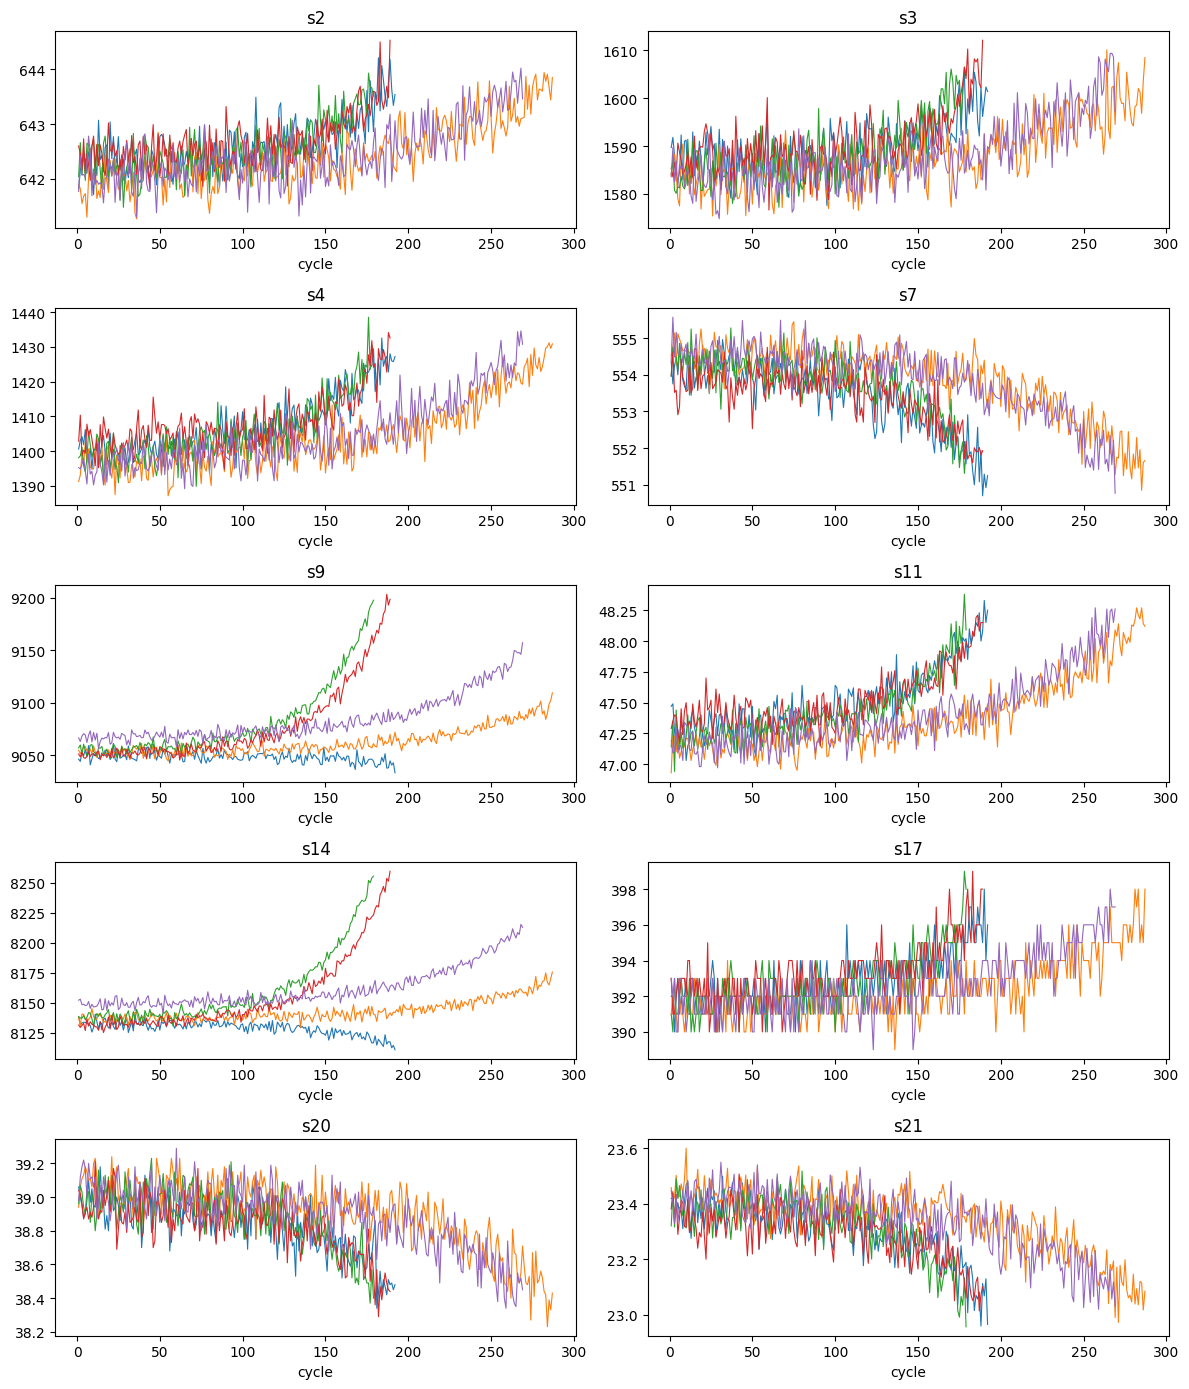

In [44]:
sensors = ["s2", "s3", "s4", "s7", "s9", "s11", "s14", "s17", "s20", "s21"]
units = [1, 2, 3, 4, 5]

fig, axes = plt.subplots(5, 2, figsize=(12, 14), sharex=False)
for ax, s in zip(axes.ravel(), sensors):
    for u in units:
        d = train[train["unit"] == u]
        ax.plot(d["cycle"], d[s], linewidth=0.8)
    ax.set_title(s)
    ax.set_xlabel("cycle")
plt.tight_layout()
plt.show()

In [45]:
import os
os.makedirs("results/figures", exist_ok=True)
fig.savefig("results/figures/sensor_degradation.png", dpi=120, bbox_inches="tight")

# **Engine lifetimes and the RUL cap**
Lifetimes range from 128 to 362 cycles (median 199). Every engine outlives 125 cycles, so capping RUL at 125 only flattens the healthy phase and never truncates real degradation.


count    100.000000
mean     206.310000
std       46.342749
min      128.000000
25%      177.000000
50%      199.000000
75%      229.250000
max      362.000000
Name: cycle, dtype: float64


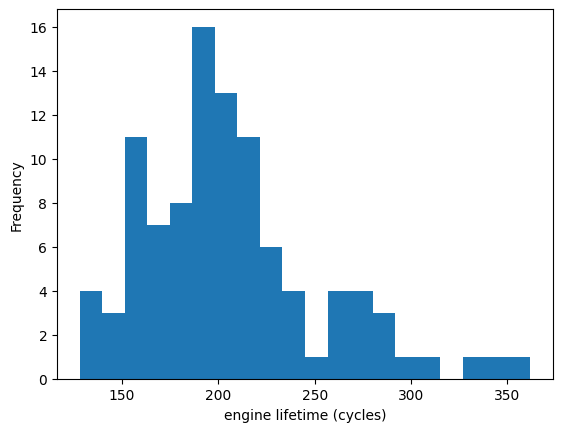

In [46]:
lifetimes = train.groupby("unit")["cycle"].max()
print(lifetimes.describe())
ax = lifetimes.plot.hist(bins=20)
ax.set_xlabel("engine lifetime (cycles)")
ax.get_figure().savefig("results/figures/lifetime_hist.png", dpi=120, bbox_inches="tight")
